In [1]:
try:
    import pytorch
except ImportError:
    #!pip3 install torch torchvision
    pass

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from torch.utils.data import Dataset
# import one hot encoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_covtype
import seaborn as sns

# Using Custom Datasets

There are many datasets that we can load via code, in addition to the pytorch ones we can also load datasets from places like Kaggle or HuggingFace if we create and account. However, we're bold leaders, not boring followers, so we need to be able to use our own data directly. This is usually pretty simple, we can create a class for our custom dataset that provides the necessary methods for PyTorch to load and use the data.

In [ ]:
BATCH_SIZE = 128
TEST_SPLIT = 0.1
VAL_SPLIT = 0.15
EPOCHS = 5
USE_WEIGHTS = False
PIN_MEMORY = False
NUM_WORKERS = 3

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA device found.", torch.cuda.is_available())
    BATCH_SIZE = 1024
    EPOCHS = 20
    PIN_MEMORY = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.", torch.backends.mps.is_available())
    BATCH_SIZE = 256
    EPOCHS = 10
else:
    device = torch.device("cpu")
    print ("MPS/GPU device not found.")

CUDA device found. True


## The Data

We have some normal tabular data. The dataset that is loaded with the fetch_covtype function is data on forest cover types, and the task is to predict the type of forest cover based on various features. It is pretty big, which is good. 

In [3]:
df = fetch_covtype(as_frame=True).frame
feature_cols = df.columns.tolist()
target_col = 'Cover_Type'
feature_cols.remove(target_col)
print(df.shape)
df.head()

(581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


## Loading Data

Managing and loading data in our PyTorch models is a bit more complex than it typically is with dataframes and scikit-learn. There's a few reasons for this, mainly that neural networks are at their best when dealing with very large datasets, so the normal process of loading the data into RAM all at once, like with an array or dataframe, is not something that'll work for most real world deep learning problems. Instead, we need to be able to load data in chunks, and often need to do some preprocessing on-the-fly as the data is being loaded. PyTorch provides two main tools to help with this: the Dataset and the DataLoader.

<b>Note:</b> there is a lot of flexibility in how these items can work, as there is with most PyTorch components. As long as the specific requirements of the class/method are met, how our code gets there can be almost anything - there's a lot more variance than with the sklearn models that we've used so far. In practice, you'll see lots of different ways to do things if you look at my examples, the text, the documentation, or things you may find online. These differences can be due to personal preference, specific needs of the data/problem, or other factors. The important part is understanding the requirements and how to meet them, rather than following a specific pattern. This is also a good chance to think agile and work iteratively; we can start with something that works, then adjust as we see both the performance of the model, and any limitations of the hardware. With some experience, you'll get a bit better at selecting a good starting point. 

### Custom Dataset

To create a custom dataset in PyTorch, we need to define a class that inherits from `torch.utils.data.Dataset`. Among other things, this class needs to convert the data into PyTorch tensors from whatever format the data is currently in (e.g., pandas DataFrame, NumPy array, etc.). For most common datatypes, the data can be fed to the tensor constructor directly. This class must implement the following methods:

<ul>
<li>`__init__`: This method initializes the dataset, loading the data and performing any necessary preprocessing.</li>
<li>`__len__`: This method returns the total number of samples in the dataset.</li>
<li>`__getitem__`: This method retrieves a sample from the dataset at the specified index.</li>
    <ul>
    <li>This item is typically returned as a tuple containing the features and the target label.</li>
    </ul>
</ul>

The dataset is responsible for managing access to the data and returning items in the correct format. For this example, we feed it a dataframe and it'll handle converting to a tensor and producing one item at a time, when asked. In other scenarios, the "access" part might be different, in particular, if we have large datasets such as images or text files that we can't fit into RAM, we might want to load the data from disk on-the-fly in the `__getitem__` method rather than loading everything into memory at once. In those cases, when to load and process the data would be mainly dependent on the specifics of the data, and the resources of the machine(s) - the priority is usually to ensure the GPU is kept running as much as possible without waiting for data to be loaded or processed.

For our data, we'll make a simple dataset that takes in a dataframe and some info about which columns to use, and produces the features and labels one at a time in the `__getitem__` method. We don't need to do too much processing, our data is already a bunch of floats, but we should scale them for the model to train effectively. We can build that into the `__init__` method so that it's done once when the dataset is created.

### Dataloader

The dataloader is the Dataset's best buddy, it takes the dataset, and manages training specific tasks such as batching, shuffling, and parallel loading. The dataloader wraps around the dataset and provides an iterable over the dataset, allowing us to easily access batches of data during training. Our primary concerns with the dataloader are:
<ul>
<li>`dataset`: The dataset from which to load the data.</li>
    <ul>
    <li>The dataset manages all the details of accessing data, the dataloader just calls the dataset's methods to get the data.</li>
    </ul>
<li>`batch_size`: How many samples per batch to load.</li>
    <ul>
    <li>Batch size is impacted by both the performance of the model and the limits of the hardware. </li>
    <li>Larger batch sizes can lead to faster training times because they allow for more parallelism and better utilization of the GPU. However, they also require more GPU memory, which is the hard limit we often run into first.</li>
    <li>Smaller batch sizes use less memory and can often lead to better generalization, but there's some 'waste' as each batch doesn't do as much processing as it could. </li>
    <li>For our smaller models, batch size of 32 or 64 is often a good starting point, but it really is a tunable parameter that we can experiment with. With some of the larger examples later, we will need to balance GPU memory with model performace to optimize the processing.</li>
    </ul>
<li>`shuffle`: Whether to shuffle the data at every epoch.</li>
    <ul>
    <li>For training data, we (almost?) always want to shuffle the data. This usually helps with generalization and convergence. If you feed the model all the True samples first, that can push the gradient descent in one direction for a long time, making it harder to converge when other samples are seen later. Shuffling ensures that the model sees a representitive mix of samples in each batch.</li>
    <li>For testing data, there's no need to shuffle, we're just running predictions (inference) on the data, so the order doesn't matter.</li>
    </ul>
</ul>

<b>Note:</b> I shifted the target values down by 1 in the dataset class, so that they start from 0 instead of 1, this is just to ensure I don't accidentally make some mistake somewhere and misindex things, like I did when I made this initially. If we were really using this data, we'd take every value as shift it up by 1 when the results are reported. 

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, feature_colnames: list, target_colname: str):
        self.x_tmp = dataframe[feature_colnames].values
        self.scaler = StandardScaler()
        self.x_tmp = self.scaler.fit_transform(self.x_tmp)
        self.X = torch.tensor(self.x_tmp, dtype=torch.float32)
        self.y = torch.tensor(dataframe[target_colname].values, dtype=torch.long)
        self.y = self.y - 1  # Subtract 1 to make classes start from 0
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

def preview_batch(dataloader, num_prints=5):
    sample_batch = next(iter(dataloader))
    inputs, targets = sample_batch
    i = 0
    for input_tensor, target in zip(inputs, targets):
        print(f"Sample {i}:")
        print(f"Input Tensor: {input_tensor}")
        print(f"Target: {target}\n")
        i += 1
        if i >= num_prints:
            break

train, test = train_test_split(df, test_size=TEST_SPLIT, random_state=42)
train, val = train_test_split(train, test_size=VAL_SPLIT, random_state=42)

train_dataset = CustomDataset(dataframe=train, feature_colnames=feature_cols, target_colname=target_col)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_dataset = CustomDataset(dataframe=test, feature_colnames=feature_cols, target_colname=target_col)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_dataset = CustomDataset(dataframe=val, feature_colnames=feature_cols, target_colname=target_col)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
preview_batch(train_dataloader)

/tmp/ipykernel_5591/2769794312.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.long)
/tmp/ipykernel_5591/2769794312.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.long)
/tmp/ipykernel_5591/2769794312.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.long)


Sample 0:
Input Tensor: tensor([-7.1844e-01,  1.0860e+00,  1.1881e+00, -4.2051e-01,  6.5965e-01,
        -1.8962e-01, -2.2469e+00,  6.9253e-01,  2.0524e+00, -1.3309e+00,
        -9.0273e-01, -2.3308e-01,  1.1382e+00, -2.6109e-01, -7.2358e-02,
        -1.1479e-01, -9.1421e-02, -1.4786e-01, -5.2957e-02, -1.0678e-01,
        -1.3333e-02, -1.7495e-02, -4.4616e-02, -2.4391e-01, -1.4775e-01,
        -2.3279e-01, -1.7517e-01, -3.2708e-02, -2.1213e-03, -7.0206e-02,
        -7.7078e-02, -5.8094e-02, -8.3123e-02, -1.2761e-01, -3.8534e-02,
        -2.4745e-01, -3.3241e-01, -1.9500e-01, -2.8312e-02, -6.6740e-02,
        -4.3643e-02, -4.0365e-02, -4.9706e-01, -2.3384e-01, -2.1477e-01,
        -3.1526e-01,  3.4426e+00, -5.2871e-02, -5.7111e-02, -1.4231e-02,
        -2.2754e-02, -1.6603e-01, -1.5628e-01, -1.2321e-01])
Target: 1

Sample 1:
Input Tensor: tensor([-1.5368e-02, -6.0319e-01, -2.8054e-01, -7.0268e-01, -6.7677e-01,
        -3.8719e-01,  9.6564e-01, -1.6721e-01, -8.5019e-01,  2.9986e-01,
    

#### Check Target Distribution

When dealing with classification problems, it's often useful to check the distribution of the target classes in the dataset. This can help identify class imbalance issues that may affect model performance. It looks like there's an imbalance here, we can consider addressing it later. 

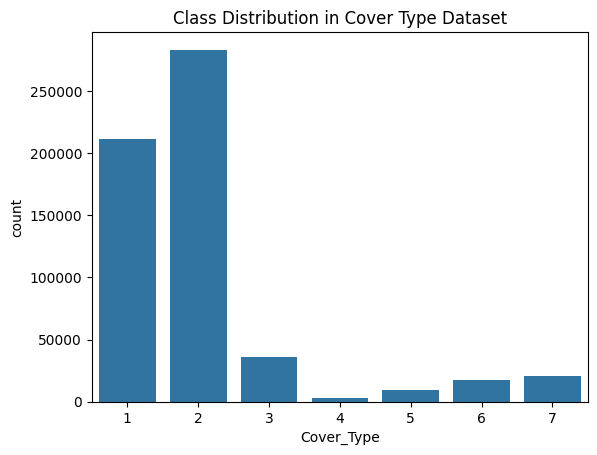

In [5]:
sns.countplot(x=target_col, data=df)
plt.title("Class Distribution in Cover Type Dataset")
plt.show()

#### Class Weights

We can calculate class weights to help with imbalanced datasets, which we can try later. The calculation used here is:

$w_i = \frac{N}{C \cdot n_i}$

Where:
- $w_i$ is the weight for class $i$.
- $N$ is the total number of samples in the dataset.
- $C$ is the total number of classes.
- $n_i$ is the number of samples in class $i$.

This formula gives higher weights to classes that have fewer samples, which can help the model learn from those classes more effectively. We can calculate these weights in the dataset class and then pass them to the loss function during training.

In [6]:
### Calculate weights for imbalanced classes
class_counts = df[target_col].value_counts().sort_index()
total_samples = len(df)
class_weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32).to(device)
print("Class weights:", class_weights_tensor)

Class weights: tensor([ 0.3918,  0.2930,  2.3215, 30.2154,  8.7435,  4.7793,  4.0469],
       device='cuda:0')


## Make a Model

We can now define our model. As with datasets, it is a bit more involved than with sklearn, as we have the ability to create all kinds of custom architectures targeted at specific problems. For this example, we'll make a simple feedforward neural network for classification. The model will consist of several linear layers with ReLU activations in between, and a final output layer with a softmax activation to produce class probabilities.

With respect to our datasets, as long as we did what we needed to do, we don't care about if the dataset was custom or premade from here on out. 

### Model Parts

There are a few parts to the model. Again, we have quite a bit of flexibility in how we implement things, as long as we meet the requirements of the PyTorch framework. The main requirement is that we define a class that inherits from `torch.nn.Module`, and implement the `__init__` and `forward` methods. Most of the logic that we saw in the by-hand example is built into the torch framework, so we can ignore most of that and provide the core bits:
<ul>
<li>`__init__`: This method initializes the model, defining the layers and any other components needed.</li>
    <ul>
    <li> The `super().__init__()` call is necessary to properly initialize the base class.</li>
    <li> Each other attribute is one of the layers of the model, defined using PyTorch's built-in layer classes.</li>
    </ul>
<li>`forward`: This method defines the forward pass of the model, specifying how the input data flows through the layers to produce the output.</li>
    <ul>
    <li> The input `x` is passed through each layer in sequence, with activation functions applied as needed.</li>
    <li> The final output is returned, which will be used for loss calculation and predictions.</li>
    <li> Note that we don't need to define the backward pass, PyTorch automatically computes gradients using autograd.</li>
    <li> Also note, we are using the layer attributes one-by-one, they aren't automatically connected in order - we have to define the flow of data explicitly in the `forward` method.</li>
    </ul>
</ul>

Below in the `SequentialModel` class there's an example of an equivalent model using the `torch.nn.Sequential` container, which allows us to define the model as a sequence of layers without explicitly defining the `forward` method. This can be more concise for simple models, but is less flexible for complex architectures. These two models are functionally equivalent - the only time we care is if we need to do something that the `Sequential` container can't handle easily.

In [7]:
#create model
# The debug thing is totally optional. 
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, debug_preds=False):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.debug_preds = debug_preds
        if debug_preds:
            print("Debugging of predictions is enabled.")
        
    def forward(self, x):
       x = self.fc1(x)
       x = self.relu(x)
       x = self.fc2(x)
       x = self.relu2(x)
       x = self.fc3(x)
       if self.debug_preds:
           print(f"Debug: Output predictions: {x}")
       return x

# This is equivalent to the SimpleNN above, but uses nn.Sequential to define the model in a more compact way.
# we can also just have the inner bit of "self.model", without the class
class SequentialModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SequentialModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        return self.model(x)

#### Define Some Constants

There are typically several things we need to configure before we can create and train the model. These include things such as the input size (number of features), epochs to train for, learning rate, etc. We'll group a bunch of the definitions here, so it is easy to find and adjust them as needed.

<b>Note:</b> There are some constants defined earlier, that's because we are looking at them bit-by-bit. In a real example, these would all be together at the top of the notebook/script.

In [8]:
LEARNING_RATE = 0.015
INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 32
OUTPUT_SIZE = len(df[target_col].value_counts())

print(f"Model Settings: Input Size={INPUT_SIZE}, Hidden Size={HIDDEN_SIZE}, Output Size={OUTPUT_SIZE}")
print(f"Training for {EPOCHS} epochs with learning rate {LEARNING_RATE}")

Model Settings: Input Size=54, Hidden Size=32, Output Size=7
Training for 20 epochs with learning rate 0.015


## Training the Model

To train the model, we first need to define a loss function and an optimizer. The loss function measures how well the model's predictions match the true labels, and the optimizer updates the model's weights based on the computed gradients to minimize the loss. The optimizer takes the model's parameters and a learning rate as input, it'll then use these to do all of the adjustments during training process, without us needing to manage the details and math ourselves.

#### Construct the Model

The model constructor makes a model object, basically the structure of all the weights and biases, but they are not useful yet. We can have parameters like the ones we included here to let us customize things. Most frequently, we can use these parameters to allow us to create different shaped/sized models without having to remake everything - if we are tuning the model, this can make it easier to try different model designs, which can radically impact performance. We can also add whatever else we want, here I added a flag to enable some debugging print statements - this came from real-life experience, I originally had made a mistake in the number of classes and had to track it down. 

#### Optimizer

The optimizer isn't a huge concern for us, but it is important. This is the algorithm that actually updates the weights based on the gradients we compute during backpropagation. There are many different ones, the Adam optimizer is a good general-purpose choice that works well in many scenarios, so it's a common default. The learning rate is a key hyperparameter that controls how big of a step we take during each update - too high and we might overshoot the optimal weights, too low and training can be very slow. The learning rate can often be tuned to improve performance. For our usage, we won't worry too much about optimizers, but in more complex scenarios, selecting and tuning the optimizer can be important. Large models like ChatGPT or a self-driving car can cost hundreds of millions of dollars to train, and take weeks of time while running on clusters of 10s of thousands of GPUs - in those cases, even small improvements in training efficiency can lead to huge cost savings, so there's a lot of research into optimizers and training techniques for those scenarios. The nerdiest people from my computer science classes, along with math grad students, tend to end up working on those problems. 

The optimizer takes an input of the model's parameters. It basically captures those parameters and manages all the reading and updating for us. 

#### Loss Function

The loss function is how the model measures the error while training, the same as with the classical models, but with a little more variety. One thing that we need to be careful of is ensuring that the:
<ul>
<li> Model's output. </li>
<li> Loss function's expected input. </li>
<li> The format of the target labels. </li>
</ul>
all match up. In this case, we are using `CrossEntropyLoss`, which expects raw scores (logits) from the model, and target labels as class indices (not one-hot encoded). In the model's structure, we can see that the final output is the logit - we don't apply activation there at all. In the dataset, we ensured that the target labels were integers starting from 0, which matches what `CrossEntropyLoss` expects. If these don't align, we'll get errors during training or poor performance.

We always need to check this, for regression it is usually simple - no activation and MSELoss. For classification, we need to be more careful about the details. Some good default choices are:
<ul>
<li> For multi-class classification (more than 2 classes): use `CrossEntropyLoss` with raw logits from the model and integer class labels (no final activation).</li>
<li> For binary classification (2 classes): use `BCEWithLogitsLoss` with raw logits from the model and binary labels (0 or 1).</li>
</ul>
These are only starting points, some scenarios perform better with different choices, like hinge loss. In general, especially for a simple multi-class problem, there are several ways to get to the final result, mainly differing in where the activation function is applied (in the model or in the loss function). Conceptually, any working configuration is doing the same thing and is interchangable, but the recommended defaults tend to perform somewhat better, for small optimization reasons. 

In the example here (down a bit lower), there's a flag to enable class weights for imbalanced classes. This is a common technique to help the model pay more attention to under-represented classes during training. The weights are calculated based on the frequency of each class in the dataset, and passed to the loss function. This way, when the model makes a mistake on a sample from a minority class, the loss will be higher, encouraging the model to learn better representations for those classes.

In [ ]:
USE_SEQUENTIAL_MODEL = False

# Define the loss function and optimizer
if USE_SEQUENTIAL_MODEL:
    model = SequentialModel(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE)

else:
    model = SimpleNN(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, output_size=OUTPUT_SIZE, debug_preds=False)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

## Training Loops

We need to manually define the loop that trains our model. Some core parts that we need to be sure to include are:
<ul>
<li> Send the model and the data to the device. We selected the device avaiable earlier, but we need to actually move the model and data to that device for processing.</li>
<li> Set the model to training mode. This is done by calling `model.train()`. Some layers behave differently during training and evaluation, so we need to set the mode appropriately.</li>
<li><b>Train for several epochs, for each:</b></li>
    <ul>
    <li> Loop over the data in batches. The dataloader provides an iterable over the dataset, yielding batches of data. For each batch:</li>
        <ul>
        <li> Zero the gradients. Before each batch, we need to zero the gradients of the model's parameters. This is done using `optimizer.zero_grad()`.</li>
        <li> Forward pass. We pass the input data through the model to get predictions.</li>
        <li> Compute the loss. We calculate the loss between the model's predictions and the true labels.</li>
        <li> Backward pass. We compute the gradients of the loss with respect to the model's parameters using `loss.backward()`.</li>
        <li> Update the weights. We update the model's parameters using the optimizer's `step()` method.</li>
        </ul>
    <li> Calculate validation metrics. After each epoch, we can evaluate the model on the validation dataset to monitor its performance and adjust hyperparameters if needed.</li>
    </ul>
</ul>

Some parts that we should pay attention to include the difference between training and evaluation modes. When in the training mode versus evaluation mode, a few things change:
<ul>
<li> Layers like dropout and batch normalization behave differently during training and evaluation. In training mode, dropout randomly zeroes some activations to prevent overfitting, while in evaluation mode, it uses all activations. Batch normalization uses batch statistics during training and running averages during evaluation.</li>
<li> We need to ensure that we set the model to evaluation mode using `model.eval()` when evaluating the model on validation or test data. This ensures that the layers behave correctly for inference.</li>
<li> During evaluation, we typically don't need to compute gradients, so we can wrap the evaluation code in a `with torch.no_grad():` block to save memory and computation.</li>
</ul>

This stuff is easy to forget (and honestly something that I kind of think PyTorch could make more automatic), so it's good to keep in mind.

In [ ]:
def train_model(model, train_dataloader, val_dataloader, criterion, optimizer, epochs):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        with torch.set_grad_enabled(True):
            for inputs, labels in train_dataloader:
                inputs, labels = inputs.to(device), labels.to(device).long()       
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                running_loss += loss.item() * inputs.size(0)
        
        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch+1}/{epochs}: \n\tTraining Loss: {epoch_loss:.4f}")
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        with torch.no_grad():
            for inputs, labels in val_dataloader:
                inputs, labels = inputs.to(device), labels.to(device).long()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
        
        val_epoch_loss = val_loss / len(val_dataloader.dataset)
        val_accuracy = correct / len(val_dataloader.dataset)
        print(f"\tValidation Loss: {val_epoch_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

def test_model(test_dataloader, model):
    model.to(device)
    model.eval()
    correct = 0
    preds_labels = []
    with torch.no_grad():
        for inputs, labels in test_dataloader:
            inputs, labels = inputs.to(device), labels.to(device).long()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            preds_labels.extend(zip(preds.cpu().numpy(), labels.cpu().numpy()))
    test_accuracy = correct / len(test_dataloader.dataset)

    return preds_labels


In [ ]:
train_model(model, train_dataloader, val_dataloader, criterion, optimizer, EPOCHS)
test_preds = test_model(test_dataloader, model)

Epoch 1/20: 
	Training Loss: 0.6108
	Validation Loss: 0.5515, Validation Accuracy: 0.7556
Epoch 2/20: 
	Training Loss: 0.4980
	Validation Loss: 0.5146, Validation Accuracy: 0.7696
Epoch 3/20: 
	Training Loss: 0.4646
	Validation Loss: 0.4606, Validation Accuracy: 0.8048
Epoch 4/20: 
	Training Loss: 0.4489
	Validation Loss: 0.4524, Validation Accuracy: 0.8077
Epoch 5/20: 
	Training Loss: 0.4348
	Validation Loss: 0.4514, Validation Accuracy: 0.8069
Epoch 6/20: 
	Training Loss: 0.4301
	Validation Loss: 0.4685, Validation Accuracy: 0.7979
Epoch 7/20: 
	Training Loss: 0.4195
	Validation Loss: 0.4414, Validation Accuracy: 0.8125
Epoch 8/20: 
	Training Loss: 0.4172
	Validation Loss: 0.4254, Validation Accuracy: 0.8205
Epoch 9/20: 
	Training Loss: 0.4155
	Validation Loss: 0.4208, Validation Accuracy: 0.8225
Epoch 10/20: 
	Training Loss: 0.4087
	Validation Loss: 0.4178, Validation Accuracy: 0.8229
Epoch 11/20: 
	Training Loss: 0.4045
	Validation Loss: 0.4449, Validation Accuracy: 0.8154
Epoch 12

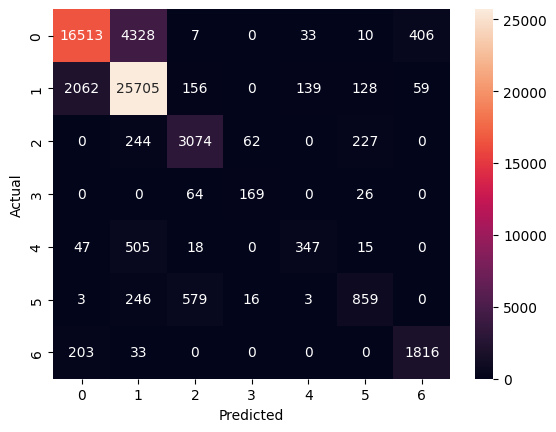

Full Dataset Accuracy: 0.8344


Text(0, 0.5, 'Accuracy')

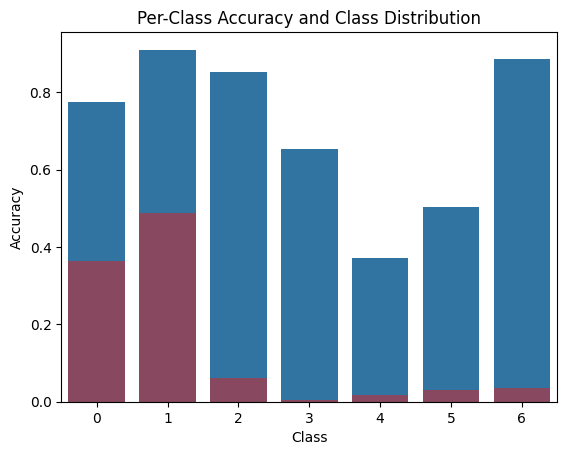

In [ ]:

full_preds = test_model(test_dataloader, model)

sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in full_preds], name='Actual'),
    pd.Series([pred for pred, _ in full_preds], name='Predicted')
), annot=True, fmt='d')
plt.show()
print(f"Full Dataset Accuracy: {len([1 for pred, label in full_preds if pred == label]) / len(full_preds):.4f}")
per_class_accuracy = {}
for pred, label in full_preds:
    if label not in per_class_accuracy:
        per_class_accuracy[label] = {'correct': 0, 'total': 0}
    per_class_accuracy[label]['total'] += 1
    if pred == label:
        per_class_accuracy[label]['correct'] += 1

sns.barplot(x=list(per_class_accuracy.keys()), y=[per_class_accuracy[label]['correct'] / per_class_accuracy[label]['total'] for label in per_class_accuracy.keys()])
class_count_percentages = class_counts / class_counts.sum()
class_count_percentages.index = class_count_percentages.index - 1  # Shift index to match class labels starting from 0
sns.barplot(x=class_count_percentages.index, y=class_count_percentages.values, alpha=0.5, color='red')
#add additional barplot with class counts
#ax = plt.gca()
#class_counts_normalized = class_counts / class_counts.max()
#sns.barplot(x=class_counts.index, y=class_counts.values, alpha=0.5, color='red')
plt.title('Per-Class Accuracy and Class Distribution')
plt.xlabel('Class')
plt.ylabel('Accuracy')

## Imbalanced Data

The data is pretty imbalanced, which can lead to poor performance on the minority classes. We can try some of the more simple ways to address the imbalance. To be honest, I rarely see substantial improvements in accuracy in these types of examples, but we are also plotting the per-class accuracies specifically to check if we've gotten better on those small minorities. 

In this case, at least most of the times I ran it, the smaller minority classes had accuracy as good, if not better, than the larger classes in the baseline above. Based on the results I got there isn't much of a need to try these techniques, but we do need the practice. A good outcome here would be a relative improvement in the balance of accuracies between classes. I've ran this several times and each run goes up or down by a percent or two, and all 3 tend to be within a few percents of each other; there's not much of a performance difference from the looks of it.

### Weighted Trial

We can use class weights to help with imbalanced datasets. This is a neural-network-y way to deal with class imbalance, when the loss is computed, it scales the impact based on the weight of that class. This can serve to equalize the importance of each class during training, helping the model to learn better representations for minority classes.

Epoch 1/20: 
	Training Loss: 0.5548
	Validation Loss: 0.5210, Validation Accuracy: 0.7392
Epoch 2/20: 
	Training Loss: 0.4928
	Validation Loss: 0.5120, Validation Accuracy: 0.7323
Epoch 3/20: 
	Training Loss: 0.4989
	Validation Loss: 0.4801, Validation Accuracy: 0.7395
Epoch 4/20: 
	Training Loss: 0.4721
	Validation Loss: 0.4600, Validation Accuracy: 0.7584
Epoch 5/20: 
	Training Loss: 0.4618
	Validation Loss: 0.5223, Validation Accuracy: 0.7488
Epoch 6/20: 
	Training Loss: 0.4599
	Validation Loss: 0.4824, Validation Accuracy: 0.7152
Epoch 7/20: 
	Training Loss: 0.4494
	Validation Loss: 0.4725, Validation Accuracy: 0.7172
Epoch 8/20: 
	Training Loss: 0.4562
	Validation Loss: 0.4628, Validation Accuracy: 0.7271
Epoch 9/20: 
	Training Loss: 0.4442
	Validation Loss: 0.4499, Validation Accuracy: 0.7676
Epoch 10/20: 
	Training Loss: 0.4423
	Validation Loss: 0.4516, Validation Accuracy: 0.7313
Epoch 11/20: 
	Training Loss: 0.4438
	Validation Loss: 0.4815, Validation Accuracy: 0.7247
Epoch 12

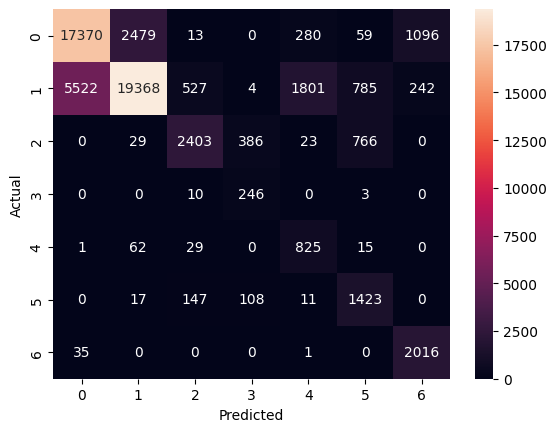

Full Dataset Accuracy with Class Weights: 0.7513


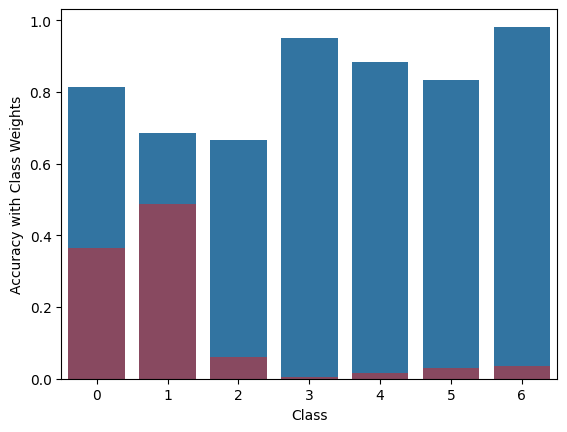

In [ ]:
criterion_weight = nn.CrossEntropyLoss(weight=class_weights_tensor)

train_model(model, train_dataloader, val_dataloader, criterion_weight, optimizer, EPOCHS)
weight_preds = test_model(test_dataloader, model)
sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in weight_preds], name='Actual'),
    pd.Series([pred for pred, _ in weight_preds], name='Predicted')
), annot=True, fmt='d')
plt.show()
print(f"Full Dataset Accuracy with Class Weights: {len([1 for pred, label in weight_preds if pred == label]) / len(weight_preds):.4f}")
per_class_weighted_accuracy = {}
for pred, label in weight_preds:
    if label not in per_class_weighted_accuracy:
        per_class_weighted_accuracy[label] = {'correct': 0, 'total': 0}
    per_class_weighted_accuracy[label]['total'] += 1
    if pred == label:
        per_class_weighted_accuracy[label]['correct'] += 1
sns.barplot(x=list(per_class_weighted_accuracy.keys()), y=[per_class_weighted_accuracy[label]['correct'] / per_class_weighted_accuracy[label]['total'] for label in per_class_weighted_accuracy.keys()])
sns.barplot(x=class_count_percentages.index, y=class_count_percentages.values, alpha=0.5, color='red')
plt.xlabel('Class')
plt.ylabel('Accuracy with Class Weights')
plt.show()

### Stratified Data Trial

We can notice that the dataset is imbalanced, with some classes having significantly more samples than others. Our predictions don't really appear to be reflecting reality for infrequent classes. 

#### Weighted Sampling

Another approach to handling imbalanced datasets is to use weighted sampling. This technique involves creating a sampler that assigns higher probabilities to samples from minority classes, ensuring that they are more likely to be included in each batch during training. 

In pytorch, we can use the `WeightedRandomSampler` class, added as an input to the dataloader, to implement this technique. By default, a dataloader will sample from the dataset uniformly, if we provide a sampler, it will use the probabilities from the sampler to draw samples instead. We can use this to force more representation from the less frequent classes. 

/tmp/ipykernel_5591/2769794312.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(self.y, dtype=torch.long)


Epoch 1/20: 
	Training Loss: 0.6027
	Validation Loss: 0.7454, Validation Accuracy: 0.6738
Epoch 2/20: 
	Training Loss: 0.4685
	Validation Loss: 0.6602, Validation Accuracy: 0.7116
Epoch 3/20: 
	Training Loss: 0.4293
	Validation Loss: 0.6415, Validation Accuracy: 0.7173
Epoch 4/20: 
	Training Loss: 0.4114
	Validation Loss: 0.5891, Validation Accuracy: 0.7406
Epoch 5/20: 
	Training Loss: 0.3959
	Validation Loss: 0.6183, Validation Accuracy: 0.7333
Epoch 6/20: 
	Training Loss: 0.3821
	Validation Loss: 0.6150, Validation Accuracy: 0.7348
Epoch 7/20: 
	Training Loss: 0.3739
	Validation Loss: 0.6020, Validation Accuracy: 0.7487
Epoch 8/20: 
	Training Loss: 0.3657
	Validation Loss: 0.5591, Validation Accuracy: 0.7605
Epoch 9/20: 
	Training Loss: 0.3647
	Validation Loss: 0.5704, Validation Accuracy: 0.7591
Epoch 10/20: 
	Training Loss: 0.3559
	Validation Loss: 0.6024, Validation Accuracy: 0.7476
Epoch 11/20: 
	Training Loss: 0.3536
	Validation Loss: 0.6007, Validation Accuracy: 0.7533
Epoch 12

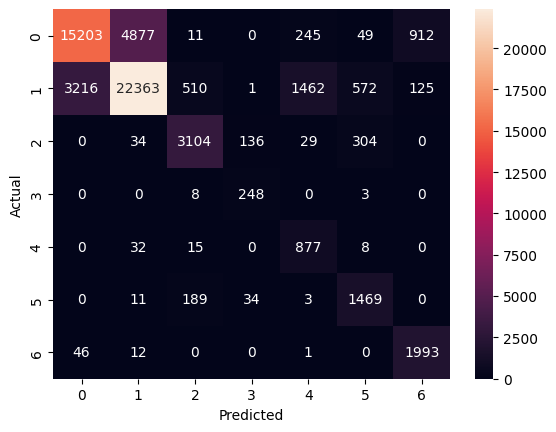

NameError: name 'class_count_percentages' is not defined

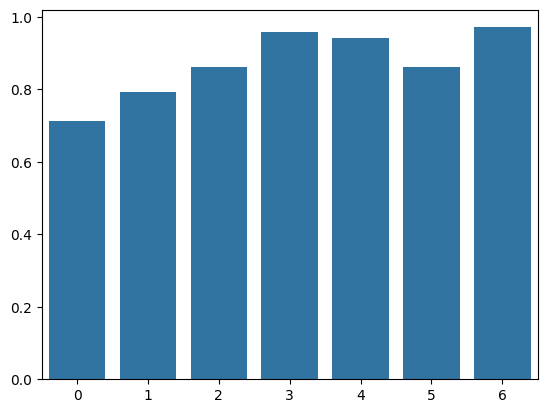

In [11]:
from torch.utils.data import Subset, WeightedRandomSampler

# Build one full dataset, then split by index (no train_test_split)
full_dataset = CustomDataset(dataframe=df, feature_colnames=feature_cols, target_colname=target_col)

num_samples = len(full_dataset)
val_size = int(0.2 * num_samples)
perm = torch.randperm(num_samples)

val_indices = perm[:val_size]
train_indices = perm[val_size:]

train_subset = Subset(full_dataset, train_indices)
val_subset = Subset(full_dataset, val_indices)

# Create class-balanced sampling weights for the training subset
train_labels = full_dataset.y[train_indices]
class_counts_train = torch.bincount(train_labels)
class_weights_train = 1.0 / class_counts_train.float()
sample_weights = class_weights_train[train_labels]

weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# Dataloaders (sampler replaces shuffle for train loader)
strat_train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=weighted_sampler)
strat_val_dataloader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

# Train/evaluate the same way as the original block
train_model(model, strat_train_dataloader, strat_val_dataloader, criterion, optimizer, EPOCHS)
strat_preds = test_model(test_dataloader, model)

sns.heatmap(pd.crosstab(
    pd.Series([label for _, label in strat_preds], name='Actual'),
    pd.Series([pred for pred, _ in strat_preds], name='Predicted')
), annot=True, fmt='d')
print("Test accuracy with WeightedRandomSampler:", len([1 for pred, label in strat_preds if pred == label]) / len(strat_preds))
plt.show()

per_class_stratified_accuracy = {}
for pred, label in strat_preds:
    if label not in per_class_stratified_accuracy:
        per_class_stratified_accuracy[label] = {'correct': 0, 'total': 0}
    per_class_stratified_accuracy[label]['total'] += 1
    if pred == label:
        per_class_stratified_accuracy[label]['correct'] += 1

sns.barplot(
    x=list(per_class_stratified_accuracy.keys()),
    y=[per_class_stratified_accuracy[label]['correct'] / per_class_stratified_accuracy[label]['total']
       for label in per_class_stratified_accuracy.keys()]
)
sns.barplot(x=class_count_percentages.index, y=class_count_percentages.values, alpha=0.5, color='red')
plt.xlabel('Class')
plt.ylabel('Accuracy with WeightedRandomSampler')
plt.show()

### Results

There's randomness, so your results may literally vary, but my results tended to have the original accuracy winning often, and the weighted one with the best, worst class. It is pretty close though, so I would not be surprised if any execution had the order rearranged. 

,Trial,Accuracy,Lowest Class Accuracy
0,Imbalanced,0.83,0.37
1,Weighted,0.75,0.67
2,Stratified,0.75,0.69


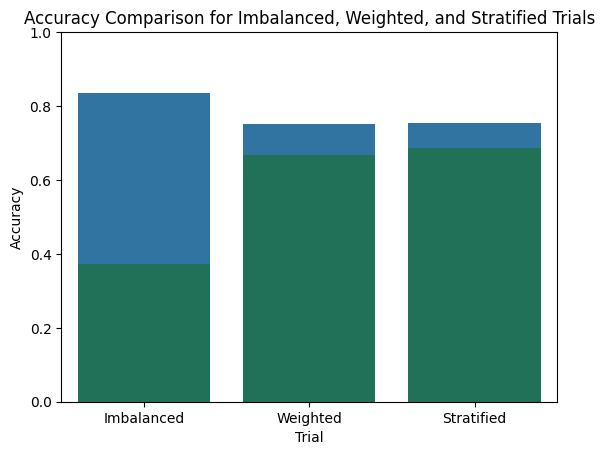

In [ ]:
df_imbalanced_accuracies = pd.DataFrame({
    "Trial": ["Imbalanced", "Weighted", "Stratified"],
    "Accuracy": [
        len([1 for pred, label in full_preds if pred == label]) / len(full_preds),
        len([1 for pred, label in weight_preds if pred == label]) / len(weight_preds),
        len([1 for pred, label in strat_preds if pred == label]) / len(strat_preds)
    ],
    "Lowest Class Accuracy": [
        min([per_class_accuracy[label]['correct'] / per_class_accuracy[label]['total'] for label in per_class_accuracy.keys()]),
        min([per_class_weighted_accuracy[label]['correct'] / per_class_weighted_accuracy[label]['total'] for label in per_class_weighted_accuracy.keys()]),
        min([per_class_stratified_accuracy[label]['correct'] / per_class_stratified_accuracy[label]['total'] for label in per_class_stratified_accuracy.keys()])
    ],
})
sns.barplot(x="Trial", y="Accuracy", data=df_imbalanced_accuracies)
sns.barplot(x="Trial", y="Lowest Class Accuracy", data=df_imbalanced_accuracies, alpha=0.5, color='green')
plt.title("Accuracy Comparison for Imbalanced, Weighted, and Stratified Trials")
plt.ylim(0, 1)
df_imbalanced_accuracies.head(10).round(2)

### Images from Disk

In [ ]:
import zipfile
import os
import urllib
import tarfile

def downloadDataset(url: str, destination: str) -> str:
    os.makedirs(destination, exist_ok=True)
    
    # Determine the filename from the URL
    file_name = url.split("/")[-1]
    file_path = os.path.join(destination, file_name)
    
    # Download the file
    if not os.path.exists(file_path):
        print(f"Downloading {url}...")
        urllib.request.urlretrieve(url, file_path)
        print(f"Downloaded to {file_path}")
    else:
        print(f"File already exists at {file_path}, skipping download.")
    
    # Extract if it's a tar/tgz/tar.gz file
    if file_path.endswith((".tgz", ".tar.gz", ".tar")):
        print(f"Extracting {file_path}...")
        with tarfile.open(file_path, "r:*") as tar:
            tar.extractall(path=destination)
        print(f"Extracted to {destination}")
    # Extract if it's a zip file
    elif file_path.endswith(".zip"):
        print(f"Extracting {file_path}...")
        with zipfile.ZipFile(file_path, "r") as zip_ref:
            zip_ref.extractall(destination)
        print(f"Extracted to {destination}")
    else:
        print("No extraction needed.")
    
    # Delete the archive file after extraction
    if file_path.endswith((".tgz", ".tar.gz", ".tar", ".zip")):
        print(f"Removing archive {file_path}...")
        os.remove(file_path)
        print(f"Removed {file_path}")
    # Find the extracted directory
    extracted_dirs = [d for d in os.listdir(destination) if os.path.isdir(os.path.join(destination, d))]
    if extracted_dirs:
        return os.path.join(destination, extracted_dirs[0])
    return file_path

In [ ]:
dataset_url = dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
destination = "data/flowers"

flower_path = downloadDataset(dataset_url, destination)
print(flower_path)


Downloaded to data/flowers/flower_photos.tgz
Extracting data/flowers/flower_photos.tgz...


/tmp/ipykernel_23768/3896913440.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=destination)


Extracted to data/flowers
Removing archive data/flowers/flower_photos.tgz...
Removed data/flowers/flower_photos.tgz
data/flowers/flower_photos


### Dataset to Read Files

Datasets that read from disk have the same requirements, but produce data differently. In this example, we:
<ul>
<li> Take in the root folder and look there for files.</li>
<li> Scan all of those subfolders to get labels.</li>
<li> In each subfolder, grab each image file's path as well as the label, add to list.</li>
<li> When an item is needed, take the next path from list, read the file, provide. </li>
</ul>

After that, we can use the pytorch version of a train/test split to divide the data. In many cases, we may either just trip a flag or use different folder paths to separate training and testing data. 

#### Note for Performance

When working with images, or large datasets requiring processing, when that processing happens is one of our concerns. In particular, we can have our CPU do the slow task or reading things from disk and doing stuff like normalizing them, while your GPU can take the last batch of data and do its work. Keeping the GPU full is a main gaol with setting up training runs, as that's normally the bottleneck and potentially the most expensive part of the process. 

In [ ]:
print(flower_path)

data/flowers/flower_photos


In [ ]:
import PIL
from torch.utils.data import random_split

class FlowerDataset(Dataset):
    def __init__(self, root_path, transform=None):
        self.path = root_path
        self.transform = transform
        self.image_paths = []
        self.labels = []
        for label in os.listdir(self.path):
            label_folder = os.path.join(self.path, label)
            if os.path.isdir(label_folder):
                for img_file in os.listdir(label_folder):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                        self.image_paths.append(os.path.join(label_folder, img_file))
                        self.labels.append(label)
        self.label_to_index = {label: idx for idx, label in enumerate(set(self.labels))}
        self.index_to_label = {idx: label for label, idx in self.label_to_index.items()}
        self.labels = [self.label_to_index[label] for label in self.labels]
        print(f"Found {len(self.image_paths)} images across {len(self.label_to_index)} classes.")
        print(f"Class to Index Mapping: {self.label_to_index}")

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = PIL.Image.open(img_path)
        if self.transform:
            image = self.transform(image)
        return image, label
    def get_labels(self):
        #return self.labels
        return self.index_to_label

In [ ]:
flower_data = FlowerDataset(flower_path)

# Split to train and validation
train_flowers, val_flowers = random_split(flower_data, [.8,.2])

flower_train_loader = DataLoader(train_flowers, batch_size=BATCH_SIZE, shuffle=True)
flower_val_loader = DataLoader(val_flowers, batch_size=BATCH_SIZE, shuffle=False)

print("Train Data:", len(train_flowers))
print("Val Data", len(val_flowers))

Found 3670 images across 5 classes.
Class to Index Mapping: {'roses': 0, 'dandelion': 1, 'tulips': 2, 'sunflowers': 3, 'daisy': 4}
Train Data: 2936
Val Data 734


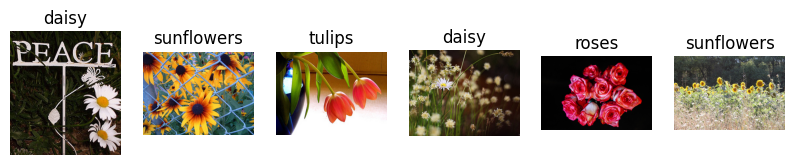

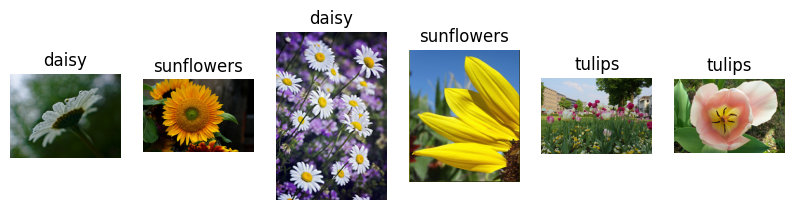

In [ ]:
def image_preview(data, num_images=4, dimensions=(180,180), color_depth=1, class_labels=None):
    fig, axes = plt.subplots(1, num_images, figsize=(10, 5))
    for i in range(num_images):
        img, label = data[i]
        #img = transforms.ToPILImage()(img)
        if np.max(np.asarray(img)) > 1:
            axes[i].imshow(np.asarray(img))
        else:
            axes[i].imshow(np.asarray(img)*255)
        axes[i].axis('off')
        if class_labels:
            axes[i].set_title(class_labels[label])
    plt.show()

labels = flower_data.get_labels()
image_preview(train_flowers, num_images=6, dimensions=(180,180), class_labels=labels,)
image_preview(val_flowers, num_images=6, dimensions=(180,180), class_labels=labels)

### Results - We Should be OK to Train!

## Exercise - Make a Model for the Flowers

Try to make a model for the flowers dataset. We'll soon use a different model structure that's better with images, but try to make it work with a fully connected feedforward network first. 

In [ ]:
# Model Time! 